In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [2]:
BASE_PATH = Path("data/beto_carrero_world/")

In [3]:
def load_data(file_path):
  files = sorted(list(file_path.glob("**/*.csv")))
  
  print(f"Found {len(files)} CSV files in {file_path}")
  
  if not files:
    print("No CSV files found in the specified directory.")
    return None
  
  dfs_list = []
  
  for file in files:
    year = file.parent.name
    month = file.stem
    
    try:
      temp_df = pd.read_csv(file)
      temp_df["year_file"] = year
      temp_df["month_file"] = month
      
      dfs_list.append(temp_df)
      print(f"Loaded {year}/{month} successfully. {len(temp_df)} records")
    except Exception as e:
      print(f"Error loading {year}/{month}: {e}")
  
  final_df = pd.concat(dfs_list, ignore_index=True)
  
  if 'last_updated_api' in final_df.columns:
    final_df['last_updated_api'] = pd.to_datetime(final_df['last_updated_api'])
    
  return final_df
 
 

In [4]:
df = load_data(BASE_PATH)

Found 40 CSV files in data\beto_carrero_world
Loaded 2023/01 successfully. 47903 records
Loaded 2023/02 successfully. 44168 records
Loaded 2023/03 successfully. 28197 records
Loaded 2023/04 successfully. 28053 records
Loaded 2023/05 successfully. 26614 records
Loaded 2023/06 successfully. 26306 records
Loaded 2023/07 successfully. 52886 records
Loaded 2023/08 successfully. 25026 records
Loaded 2023/09 successfully. 33232 records
Loaded 2023/10 successfully. 54760 records
Loaded 2023/11 successfully. 52146 records
Loaded 2023/12 successfully. 52400 records
Loaded 2024/01 successfully. 52511 records
Loaded 2024/02 successfully. 53155 records
Loaded 2024/03 successfully. 60031 records
Loaded 2024/04 successfully. 37722 records
Loaded 2024/05 successfully. 33977 records
Loaded 2024/06 successfully. 32061 records
Loaded 2024/07 successfully. 60690 records
Loaded 2024/08 successfully. 54322 records
Loaded 2024/09 successfully. 53548 records
Loaded 2024/10 successfully. 55197 records
Loaded 2

In [5]:
# Criar uma tabela de referência de tudo que você já tem no DF principal
referencia_rides = df[['id', 'name']].drop_duplicates().sort_values(by='name')

print("--- ATRAÇÕES ATUALMENTE NO DATAFRAME ---")
print(referencia_rides)

# Verificar se os "problemáticos" aparecem com outro nome
for atracao in ['Rebuliço', 'Spin Blast', 'Super Soaker Splash', 'Xícaras Malucas']:
    if atracao in referencia_rides['name'].values:
        print(f"✅ {atracao} encontrado!")
    else:
        print(f"❌ {atracao} NÃO encontrado. Verificando nomes similares...")
        # Busca nomes que contenham parte do texto (ex: busca 'Spin' em vez de 'Spin Blast')
        similares = referencia_rides[referencia_rides['name'].str.contains(atracao.split()[0], case=False, na=False)]
        if not similares.empty:
            print(f"   Talvez seja um destes: \n{similares}")

--- ATRAÇÕES ATUALMENTE NO DATAFRAME ---
              id                               name
2        11329.0              Autopista (bate-bate)
9        11330.0                      Baby Elefante
10       11340.0                       Barco Pirata
159      13872.0                 Betinho Carrero 2D
1512067  11459.0                           Big Drop
1        11334.0                          Big Tower
273      11366.0                Carrossel Veneziano
4        11344.0                 Ferrovia DinoMagic
8        11327.0                           FireWhip
0        11338.0  Madagascar Crazy River Adventure!
5        11368.0             Montanha-russa Dum Dum
3        11326.0                          Pedalinho
14       11367.0                         Raskapuska
42679    11444.0                           Rebuliço
16       11328.0                       Roda-Gigante
360024   12325.0                         Spin Blast
19       11335.0                      Star Mountain
362052   12326.0       

In [ ]:
def auditoria_dados_mensais(df_input):
    # 1. Criar uma coluna combinada de Ano-Mês para as 40 linhas
    # Usamos o year_file e month_file que você criou no load_data
    df_audit = df_input.copy()
    df_audit['periodo'] = df_audit['year_file'].astype(str) + "-" + df_audit['month_file'].astype(str).str.zfill(2)
    
    # 2. Pivotar: Índices são os períodos, Colunas são os nomes das atrações
    # Vamos contar quantos registros existem para cada cruzamento
    matriz = df_audit.pivot_table(
        index='periodo', 
        columns='name', 
        values='wait_time', 
        aggfunc='count'
    )
    
    # 3. Transformar em presença (1 se tem dado, 0 se não tem)
    matriz_presenca = matriz.notnull().astype(int)
    
    return matriz_presenca

# Gerar a matriz
matriz_resumo = auditoria_dados_mensais(df)

# Exibir com um estilo visual para facilitar a detecção de buracos
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))
sns.heatmap(matriz_resumo, cmap="YlGn", cbar=False, linewidths=.5)
plt.title("Matriz de Disponibilidade de Dados: Atração vs Mês/Ano")
plt.xlabel("Atração")
plt.ylabel("Período (Ano-Mês)")
plt.show()

In [ ]:
def auditoria_dados_diaria(df_input):
    df_audit = df_input.copy()
    
    # 1. Garantir que a coluna de data esteja no formato correto
    # Se você seguiu o tratamento anterior, ela se chama 'data_local'
    df_audit['data_local'] = pd.to_datetime(df_audit['data_local'])
    
    # 2. Criar a matriz: LINHA (Data) x COLUNA (Atração)
    # Contamos o wait_time para saber quantos registros temos por dia
    matriz_diaria = df_audit.pivot_table(
        index='data_local', 
        columns='name', 
        values='wait_time', 
        aggfunc='count'
    )
    
    # 3. Preencher datas faltantes (importante para ver buracos onde o script não rodou)
    # Criamos um range completo do início ao fim dos seus dados
    idx = pd.date_range(matriz_diaria.index.min(), matriz_diaria.index.max())
    matriz_diaria = matriz_diaria.reindex(idx)
    
    # 4. Converter para binário: 1 se tem dado (qualquer quantidade), 0 se está vazio
    matriz_presenca = matriz_diaria.notnull().astype(int)
    
    return matriz_presenca

# Executar Auditoria
matriz_diaria_resumo = auditoria_dados_diaria(df)

# --- VISUALIZAÇÃO ---
# Como a matriz diária é muito grande, vamos plotar apenas o último ano 
# ou aumentar muito a altura do gráfico.
# --- VISUALIZAÇÃO CORRIGIDA ---
# --- VISUALIZAÇÃO COM LINHAS HORIZONTAIS ---
plt.figure(figsize=(25, 300)) 

# 1. Criar o heatmap
# Mantemos linewidths=0 para a cor do dado ser contínua
ax = sns.heatmap(
    matriz_diaria_resumo, 
    cmap="Blues", 
    cbar=False, 
    linewidths=0
)

plt.title("Auditoria de Dados Diária - Presença de Registros por Atração", fontsize=20, pad=20)
plt.xlabel("Atrações", fontsize=14)
plt.ylabel("Data (Dia a Dia)", fontsize=14)

# 2. Configuração dos Ticks (Marcadores)
n = 15  
indices = np.arange(0, len(matriz_diaria_resumo), n)
labels = [matriz_diaria_resumo.index[i].strftime('%d/%m/%Y') for i in indices]

# Definir os nomes nas datas
plt.yticks(indices + 0.5, labels, rotation=0, fontsize=10) 
plt.xticks(rotation=45, ha='right', fontsize=10)

# --- O PULO DO GATO: LINHAS HORIZONTAIS ---
# Desenhamos uma linha para cada 'tick' de data para guiar a leitura
# O hlines recebe: posição Y, X inicial, X final
ax.hlines(indices, *ax.get_xlim(), colors='lightgray', linewidth=1, alpha=0.5)

# Opcional: Adicionar linhas verticais para separar as atrações também
ax.vlines(np.arange(len(matriz_diaria_resumo.columns)), *ax.get_ylim(), colors='whitesmoke', linewidth=0.5)

plt.tight_layout()
plt.show()

In [9]:
from datetime import timedelta

import pandas as pd
import numpy as np
from pathlib import Path

# --- CONFIGURAÇÕES ---
REPO_ANTIGO = Path("../bcw-queue")

def auditoria_especifica(df_dados, path_calendario):
    print("Iniciando auditoria específica...")
    
    # 1. Carregar e preparar Calendário
    df_cal = pd.read_excel(path_calendario)
    df_cal['date'] = pd.to_datetime(df_cal['date']).dt.date
    
    # Filtrar apenas dias que o parque abriu
    df_cal = df_cal[df_cal['park_open'] == True].copy()
    
    # 2. Preparar os Dados de Espera
    df_wait = df_dados.copy()
    df_wait['data_local'] = pd.to_datetime(df_wait['data_local']).dt.date
    
    # 3. Cálculo do Valor Ideal por Dia
    # Precisamos saber quantas horas o parque ficou aberto em cada data
    def calcular_ideal(row):
        try:
            # Garante que temos strings ou objetos conversíveis
            open_str = str(row['park_opening_time'])
            close_str = str(row['park_closing_time'])
            
            # Converte para datetime para calcular a diferença
            fmt = '%H:%M:%S'
            t1 = datetime.strptime(open_str, fmt)
            t2 = datetime.strptime(close_str, fmt)
            
            # Se o fechamento for "00:00:00" ou similar, pode ser erro de virada de dia
            if t2 <= t1:
                t2 += timedelta(days=1)
                
            horas_operacao = (t2 - t1).total_seconds() / 3600
            
            # 12 registros por hora * Horas * 22 atrações alvo
            return int(horas_operacao * 12 * 22)
        except Exception as e:
            # Se falhar, retorna um valor base (ex: 9 horas padrão)
            return int(9 * 12 * 22)

    from datetime import datetime
    df_cal['valor_ideal_diario'] = df_cal.apply(calcular_ideal, axis=1)

    # 4. Agrupar dados coletados por dia
    # Qtd Total de dados
    resumo_total = df_wait.groupby('data_local').size().reset_index(name='qtd_dados')
    
    # Qtd de dados > 0 (brinquedo aberto com fila)
    resumo_abertos = df_wait[df_wait['wait_time'] > 0].groupby('data_local').size().reset_index(name='qtd_dados_maior_zero')
    
    # 5. Merge Final (Baseado no Calendário de Parques Abertos)
    relatorio = df_cal.merge(resumo_total, left_on='date', right_on='data_local', how='left')
    relatorio = relatorio.merge(resumo_abertos, on='data_local', how='left')
    
    # Preencher dias que o parque abriu mas não coletamos NADA
    relatorio['qtd_dados'] = relatorio['qtd_dados'].fillna(0)
    relatorio['qtd_dados_maior_zero'] = relatorio['qtd_dados_maior_zero'].fillna(0)
    
    # 6. Cálculos de Performance
    relatorio['percentual_ideal'] = (relatorio['qtd_dados'] / relatorio['valor_ideal_diario']) * 100
    relatorio['percentual_maior_zero_ideal'] = (relatorio['qtd_dados_maior_zero'] / relatorio['valor_ideal_diario']) * 100
    
    # Limpar colunas desnecessárias
    colunas_finais = [
        'date', 'park_opening_time', 'park_closing_time', 'valor_ideal_diario',
        'qtd_dados', 'qtd_dados_maior_zero', 'percentual_ideal', 'percentual_maior_zero_ideal'
    ]
    
    return relatorio[colunas_finais].sort_values('date')

# --- EXECUÇÃO ---
df_auditoria_final = auditoria_especifica(df, REPO_ANTIGO / "calendario_operacao.xlsx")

# Visualizar dias com falha crítica (menos de 50% de coleta)
falhas_criticas = df_auditoria_final[df_auditoria_final['percentual_ideal'] < 50]

print(f"\n--- RESUMO DE AUDITORIA ---")
print(f"Total de dias operacionais analisados: {len(df_auditoria_final)}")
print(f"Dias com menos de 50% de dados: {len(falhas_criticas)}")

display(df_auditoria_final.head(20))

Iniciando auditoria específica...

--- RESUMO DE AUDITORIA ---
Total de dias operacionais analisados: 1359
Dias com menos de 50% de dados: 326


,date,park_opening_time,park_closing_time,valor_ideal_diario,qtd_dados,qtd_dados_maior_zero,percentual_ideal,percentual_maior_zero_ideal
0,2023-01-01,10:00:00,19:00:00,2376,1589.0,1589.0,66.877104,66.877104
1,2023-01-02,10:00:00,19:00:00,2376,1548.0,1548.0,65.151515,65.151515
2,2023-01-03,10:00:00,19:00:00,2376,1514.0,1514.0,63.720539,63.720539
3,2023-01-04,10:00:00,19:00:00,2376,1588.0,1588.0,66.835017,66.835017
4,2023-01-05,10:00:00,19:00:00,2376,1576.0,1576.0,66.329966,66.329966
5,2023-01-06,10:00:00,19:00:00,2376,1567.0,1567.0,65.951178,65.951178
6,2023-01-07,10:00:00,19:00:00,2376,1551.0,1551.0,65.277778,65.277778
7,2023-01-08,10:00:00,19:00:00,2376,1574.0,1574.0,66.245791,66.245791
8,2023-01-09,10:00:00,19:00:00,2376,1590.0,1590.0,66.919192,66.919192
9,2023-01-10,10:00:00,19:00:00,2376,1533.0,1533.0,64.520202,64.520202


In [13]:
import pandas as pd
import numpy as np
from datetime import date, datetime

# 1. Preparar o DataFrame para exibição
df_tabela = df_auditoria_final.copy()

# Selecionar e renomear colunas
colunas = {
    'date': 'Data',
    'qtd_dados': 'Qtd Total',
    'qtd_dados_maior_zero': 'Qtd > 0',
    'percentual_ideal': '% Coleta',
    'percentual_maior_zero_ideal': '% Ativo'
}
df_tabela = df_tabela[list(colunas.keys())].rename(columns=colunas)

# 2. Aplicar a estilização
styler = df_tabela.style.background_gradient(
    cmap='RdYlGn',        # Vermelho -> Amarelo -> Verde
    subset=['% Coleta', '% Ativo'],
    vmin=0, vmax=100
).format({
    '% Coleta': '{:.2f}%',
    '% Ativo': '{:.2f}%',
    # Correção do formatador de data para evitar o TypeError
    'Data': lambda x: x.strftime('%d/%m/%Y') if hasattr(x, 'strftime') else str(x)
})

# 3. Exibição
# Se a tabela for muito longa, podemos limitar para ver os piores casos primeiro:
# styler = styler.reindex(df_tabela.sort_values('% Coleta').index)

styler

,Data,Qtd Total,Qtd > 0,% Coleta,% Ativo
0,01/01/2023,1589.000000,1589.000000,66.88%,66.88%
1,02/01/2023,1548.000000,1548.000000,65.15%,65.15%
2,03/01/2023,1514.000000,1514.000000,63.72%,63.72%
3,04/01/2023,1588.000000,1588.000000,66.84%,66.84%
4,05/01/2023,1576.000000,1576.000000,66.33%,66.33%
5,06/01/2023,1567.000000,1567.000000,65.95%,65.95%
6,07/01/2023,1551.000000,1551.000000,65.28%,65.28%
7,08/01/2023,1574.000000,1574.000000,66.25%,66.25%
8,09/01/2023,1590.000000,1590.000000,66.92%,66.92%
9,10/01/2023,1533.000000,1533.000000,64.52%,64.52%


In [14]:
# 1. Adicionar a lógica de comparação no DataFrame
df_tabela['Dados_Iguais'] = df_tabela['Qtd Total'] == df_tabela['Qtd > 0']

# 2. Criar uma função de estilização para a nova coluna
def alert_equality(val):
    color = 'orange' if val else 'white'
    return f'background-color: {color}; color: {"black" if val else "white"}'

# 3. Gerar a visualização atualizada
styler = df_tabela.style.background_gradient(
    cmap='RdYlGn',
    subset=['% Coleta', '% Ativo'],
    vmin=0, vmax=100
).applymap(
    alert_equality, 
    subset=['Dados_Iguais']
).format({
    '% Coleta': '{:.2f}%',
    '% Ativo': '{:.2f}%',
    'Data': lambda x: x.strftime('%d/%m/%Y') if hasattr(x, 'strftime') else str(x),
    'Dados_Iguais': lambda x: '⚠️ IGUAIS' if x else '✓ OK'
})

styler

C:\Users\Luis PC\AppData\Local\Temp\ipykernel_14388\1726269871.py:14: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  ).applymap(


,Data,Qtd Total,Qtd > 0,% Coleta,% Ativo,Dados_Iguais
0,01/01/2023,1589.000000,1589.000000,66.88%,66.88%,⚠️ IGUAIS
1,02/01/2023,1548.000000,1548.000000,65.15%,65.15%,⚠️ IGUAIS
2,03/01/2023,1514.000000,1514.000000,63.72%,63.72%,⚠️ IGUAIS
3,04/01/2023,1588.000000,1588.000000,66.84%,66.84%,⚠️ IGUAIS
4,05/01/2023,1576.000000,1576.000000,66.33%,66.33%,⚠️ IGUAIS
5,06/01/2023,1567.000000,1567.000000,65.95%,65.95%,⚠️ IGUAIS
6,07/01/2023,1551.000000,1551.000000,65.28%,65.28%,⚠️ IGUAIS
7,08/01/2023,1574.000000,1574.000000,66.25%,66.25%,⚠️ IGUAIS
8,09/01/2023,1590.000000,1590.000000,66.92%,66.92%,⚠️ IGUAIS
9,10/01/2023,1533.000000,1533.000000,64.52%,64.52%,⚠️ IGUAIS


In [16]:
import pandas as pd
import numpy as np
from datetime import date, datetime

# 1. Configurações de Corte
DATA_CORTE = date(2026, 4, 7)

# 2. Preparar os dados
df_analise = df_auditoria_final.copy()
df_analise['date'] = pd.to_datetime(df_analise['date']).dt.date
df_analise = df_analise[df_analise['date'] <= DATA_CORTE]

# 3. Lógica de Investigação
# Condição 1: Qtd Total != Qtd > 0
# Condição 2: % de Coleta < 50%
df_analise['Recuperar?'] = (
    (df_analise['qtd_dados'] != df_analise['qtd_dados_maior_zero']) | 
    (df_analise['percentual_ideal'] < 50)
)

# 4. Limpeza de tipos (Removendo os .0 dos inteiros)
df_analise['qtd_dados'] = df_analise['qtd_dados'].fillna(0).astype(int)
df_analise['qtd_dados_maior_zero'] = df_analise['qtd_dados_maior_zero'].fillna(0).astype(int)

# 5. Seleção e renomeação para exibição
colunas = {
    'date': 'Data',
    'qtd_dados': 'Total',
    'qtd_dados_maior_zero': 'Qtd > 0',
    'percentual_ideal': '% Coleta',
    'percentual_maior_zero_ideal': '% Ativo',
    'Recuperar?': 'Ação'
}
df_tabela = df_analise[list(colunas.keys())].rename(columns=colunas)

# 6. Estilização Visual
def highlight_action(val):
    color = '#ff4d4d' if val == '🔍 INVESTIGAR' else '#2ecc71'
    return f'color: white; background-color: {color}; font-weight: bold; text-align: center'

styler = df_tabela.style.background_gradient(
    cmap='RdYlGn',
    subset=['% Coleta', '% Ativo'],
    vmin=0, vmax=100
).applymap(
    highlight_action,
    subset=['Ação']
).format({
    'Data': lambda x: x.strftime('%d/%m/%Y') if hasattr(x, 'strftime') else str(x),
    'Total': '{:d}',        # Força exibição como inteiro
    'Qtd > 0': '{:d}',     # Força exibição como inteiro
    '% Coleta': '{:.2f}%',
    '% Ativo': '{:.2f}%',
    'Ação': lambda x: '🔍 INVESTIGAR' if x else '✅ OK'
})

styler

C:\Users\Luis PC\AppData\Local\Temp\ipykernel_14388\1912200744.py:45: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  ).applymap(


,Data,Total,Qtd > 0,% Coleta,% Ativo,Ação
0,01/01/2023,1589,1589,66.88%,66.88%,✅ OK
1,02/01/2023,1548,1548,65.15%,65.15%,✅ OK
2,03/01/2023,1514,1514,63.72%,63.72%,✅ OK
3,04/01/2023,1588,1588,66.84%,66.84%,✅ OK
4,05/01/2023,1576,1576,66.33%,66.33%,✅ OK
5,06/01/2023,1567,1567,65.95%,65.95%,✅ OK
6,07/01/2023,1551,1551,65.28%,65.28%,✅ OK
7,08/01/2023,1574,1574,66.25%,66.25%,✅ OK
8,09/01/2023,1590,1590,66.92%,66.92%,✅ OK
9,10/01/2023,1533,1533,64.52%,64.52%,✅ OK


--- BALANÇO GERAL DA BASE DE DADOS ---
             Status  Quantidade de Dias Percentual
      Saudável (OK)                 848     77.73%
Requer Investigação                 243     22.27%


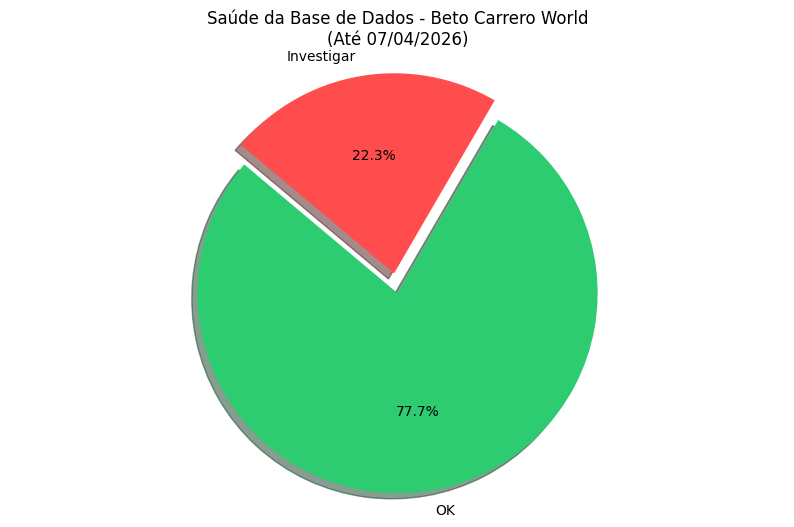

In [19]:
# 1. Calcular o balanço de dados
total_dias = len(df_tabela)
dias_ok = (df_tabela['Ação'] == False).sum()
dias_investigar = (df_tabela['Ação'] == True).sum()

percentual_saudavel = (dias_ok / total_dias) * 100

# 2. Criar um mini DataFrame de resumo para exibição limpa
df_resumo = pd.DataFrame({
    'Status': ['Saudável (OK)', 'Requer Investigação'],
    'Quantidade de Dias': [dias_ok, dias_investigar],
    'Percentual': [f"{percentual_saudavel:.2f}%", f"{100 - percentual_saudavel:.2f}%"]
})

print("--- BALANÇO GERAL DA BASE DE DADOS ---")
print(df_resumo.to_string(index=False))

# 3. Visualização Gráfica
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#ff4d4d']
explode = (0.1, 0)  # Destaca a fatia de "OK"

plt.pie(
    [dias_ok, dias_investigar], 
    labels=['OK', 'Investigar'], 
    autopct='%1.1f%%',
    startangle=140, 
    colors=colors,
    explode=explode,
    shadow=True
)

plt.title(f"Saúde da Base de Dados - Beto Carrero World\n(Até {DATA_CORTE.strftime('%d/%m/%Y')})")
plt.axis('equal') 
plt.show()

In [20]:
import pandas as pd
from pathlib import Path

# 1. Filtrar apenas os dados que precisam de investigação
df_pendencias = df_tabela[df_tabela['Ação'] == True].copy()

# 2. Adicionar uma coluna de "Motivo da Investigação" para facilitar seu trabalho no Excel
def definir_motivo(row):
    motivos = []
    if row['Total'] != row['Qtd > 0']:
        motivos.append("Dados Iguais (Falta registro zero)")
    if float(row['% Coleta'].replace('%', '')) < 50:
        motivos.append("Baixa Coleta (< 50%)")
    return " / ".join(motivos)

# Aplicando a lógica de motivos (usando os nomes das colunas originais do df_analise antes da renomeação se necessário)
df_pendencias['Motivo da Investigação'] = df_analise[df_analise['Recuperar?'] == True].apply(
    lambda row: " / ".join([
        "Dados Iguais" if row['qtd_dados'] == row['qtd_dados_maior_zero'] else "",
        "Baixa Coleta" if row['percentual_ideal'] < 50 else ""
    ]).strip(" / "), axis=1
)

# 3. Exportar para Excel
nome_arquivo = f"investigacao_pendencias_{datetime.now().strftime('%Y%m%d')}.xlsx"

# Usando o ExcelWriter para formatar as colunas
with pd.ExcelWriter(nome_arquivo, engine='openpyxl') as writer:
    df_pendencias.to_excel(writer, index=False, sheet_name='Pendências')
    
    # Ajuste básico de largura de colunas (opcional, mas ajuda na leitura)
    worksheet = writer.sheets['Pendências']
    for col in worksheet.columns:
        max_length = 0
        column = col[0].column_letter
        for cell in col:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except: pass
        worksheet.column_dimensions[column].width = max_length + 2

print(f"✅ Arquivo '{nome_arquivo}' gerado com sucesso!")
print(f"Total de {len(df_pendencias)} datas exportadas para investigação.")

✅ Arquivo 'investigacao_pendencias_20260420.xlsx' gerado com sucesso!
Total de 243 datas exportadas para investigação.


In [23]:
import pandas as pd
import numpy as np
from datetime import date, datetime

# --- CONFIGURAÇÕES ---
DATA_CORTE = date(2026, 4, 7)
LIMIAR_DIVERGENCIA = 0.10  # 10% - Se a diferença (zeros) for maior que 10%, investigamos.

# --- PREPARAÇÃO ---
df_analise = df_auditoria_final.copy()
df_analise['date'] = pd.to_datetime(df_analise['date']).dt.date
df_analise = df_analise[df_analise['date'] <= DATA_CORTE]

# Garantir números limpos
df_analise['qtd_dados'] = df_analise['qtd_dados'].fillna(0)
df_analise['qtd_dados_maior_zero'] = df_analise['qtd_dados_maior_zero'].fillna(0)

# Calcular a diferença (os registros que são zero)
df_analise['qtd_zeros'] = df_analise['qtd_dados'] - df_analise['qtd_dados_maior_zero']

# Proporção da divergência
df_analise['prop_divergencia'] = np.where(
    df_analise['qtd_dados'] > 0, 
    df_analise['qtd_zeros'] / df_analise['qtd_dados'], 
    0
)

# --- NOVA LÓGICA DE DECISÃO ---
# 1. Investigar se Coleta < 50%
condicao_baixa_coleta = df_analise['percentual_ideal'] < 50

# 2. Investigar se a Quantidade Total é muito diferente da Quantidade Maior que Zero
# (Ou seja, se a proporção de zeros for maior que o limiar definido)
condicao_divergencia_alta = df_analise['prop_divergencia'] > LIMIAR_DIVERGENCIA

df_analise['Recuperar?'] = condicao_baixa_coleta | condicao_divergencia_alta

# --- MOTIVO ---
def explicar_motivo(row):
    motivos = []
    if row['percentual_ideal'] < 50:
        motivos.append("Baixa Coleta")
    if row['prop_divergencia'] > LIMIAR_DIVERGENCIA:
        motivos.append(f"Divergência Alta ({row['prop_divergencia']*100:.1f}% zeros)")
    return " / ".join(motivos)

df_analise['Motivo'] = df_analise.apply(explicar_motivo, axis=1)

# --- TABELA VISUAL ---
colunas_show = {
    'date': 'Data',
    'qtd_dados': 'Total',
    'qtd_dados_maior_zero': 'Qtd > 0',
    'qtd_zeros': 'Diferença',
    'percentual_ideal': '% Coleta',
    'Recuperar?': 'Ação'
}
df_tabela = df_analise[list(colunas_show.keys()) + ['Motivo']].rename(columns=colunas_show)

styler = df_tabela.style.background_gradient(
    cmap='RdYlGn',
    subset=['% Coleta'],
    vmin=0, vmax=100
).applymap(
    lambda v: 'color: white; background-color: #ff4d4d; font-weight: bold' if v == True else 'color: #2ecc71',
    subset=['Ação']
).format({
    'Data': lambda x: x.strftime('%d/%m/%Y') if hasattr(x, 'strftime') else str(x),
    'Total': '{:.0f}',
    'Qtd > 0': '{:.0f}',
    'Diferença': '{:.0f}',
    '% Coleta': '{:.2f}%',
    'Ação': lambda x: '🔍 INVESTIGAR' if x else '✅ OK'
})

styler

C:\Users\Luis PC\AppData\Local\Temp\ipykernel_14388\2495799262.py:64: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  ).applymap(


,Data,Total,Qtd > 0,Diferença,% Coleta,Ação,Motivo
0,01/01/2023,1589,1589,0,66.88%,✅ OK,
1,02/01/2023,1548,1548,0,65.15%,✅ OK,
2,03/01/2023,1514,1514,0,63.72%,✅ OK,
3,04/01/2023,1588,1588,0,66.84%,✅ OK,
4,05/01/2023,1576,1576,0,66.33%,✅ OK,
5,06/01/2023,1567,1567,0,65.95%,✅ OK,
6,07/01/2023,1551,1551,0,65.28%,✅ OK,
7,08/01/2023,1574,1574,0,66.25%,✅ OK,
8,09/01/2023,1590,1590,0,66.92%,✅ OK,
9,10/01/2023,1533,1533,0,64.52%,✅ OK,


In [24]:
import pandas as pd
from datetime import datetime

# 1. Isolar apenas as datas que requerem investigação
df_pendencias = df_analise[df_analise['Recuperar?'] == True].copy()

# 2. Selecionar colunas relevantes para o seu trabalho no Excel
# Removendo colunas auxiliares e mantendo o que importa para a análise
colunas_excel = [
    'date', 
    'park_opening_time', 
    'park_closing_time', 
    'valor_ideal_diario', 
    'qtd_dados', 
    'qtd_dados_maior_zero', 
    'qtd_zeros', 
    'percentual_ideal', 
    'prop_divergencia',
    'Motivo'
]

# Garantir que a seleção existe (evitar erro se alguma coluna foi renomeada)
df_export = df_pendencias[colunas_excel].copy()

# 3. Renomear colunas para o Excel ficar "amigável"
df_export.columns = [
    'Data', 'Abertura', 'Fechamento', 'Ideal (Registros)', 
    'Total Coletado', 'Qtd > 0 min', 'Qtd = 0 min (Diferença)', 
    '% Eficiência Coleta', '% Divergência (Zeros)', 'Motivo da Investigação'
]

# 4. Exportação para Excel com formatação básica
data_hoje = datetime.now().strftime('%Y-%m-%d_%H-%M')
nome_arquivo = f"investigacao_parque_{data_hoje}.xlsx"

try:
    with pd.ExcelWriter(nome_arquivo, engine='openpyxl') as writer:
        df_export.to_excel(writer, index=False, sheet_name='Datas_Suspeitas')
        
        # Auto-ajuste de colunas
        worksheet = writer.sheets['Datas_Suspeitas']
        for col in worksheet.columns:
            max_length = 0
            column = col[0].column_letter
            for cell in col:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except: pass
            worksheet.column_dimensions[column].width = max_length + 2

    print(f"✅ Sucesso! Foram encontradas {len(df_export)} datas suspeitas.")
    print(f"📂 Arquivo gerado: {nome_arquivo}")

except Exception as e:
    print(f"❌ Erro ao gerar Excel: {e}")

# Exibir as primeiras linhas do que foi exportado para conferência
df_export.head()

✅ Sucesso! Foram encontradas 174 datas suspeitas.
📂 Arquivo gerado: investigacao_parque_2026-04-20_13-40.xlsx


,Data,Abertura,Fechamento,Ideal (Registros),Total Coletado,Qtd > 0 min,Qtd = 0 min (Diferença),% Eficiência Coleta,% Divergência (Zeros),Motivo da Investigação
294,2023-12-30,10:00:00,19:00:00,2376,1073.0,1073.0,0.0,45.159933,0.0,Baixa Coleta
431,2024-06-08,10:00:00,19:00:00,2376,396.0,396.0,0.0,16.666667,0.0,Baixa Coleta
515,2024-09-09,10:00:00,19:00:00,2376,318.0,318.0,0.0,13.383838,0.0,Baixa Coleta
598,2024-12-01,10:00:00,19:00:00,2376,176.0,176.0,0.0,7.407407,0.0,Baixa Coleta
669,2025-02-10,10:00:00,19:00:00,2376,95.0,95.0,0.0,3.998316,0.0,Baixa Coleta


In [25]:
import pandas as pd
from datetime import date, datetime

# 1. Filtro de Horizonte e Definição de Falha
DATA_CORTE = date(2026, 4, 7)
MIN_COLETA = 50.0  # % mínimo aceitável

# 2. Filtrar apenas dias com baixa coleta (abaixo de 50%)
df_baixa_coleta = df_analise[
    (df_analise['date'] <= DATA_CORTE) & 
    (df_analise['percentual_ideal'] < MIN_COLETA)
].copy()

# 3. Organizar colunas para o seu check-list
df_baixa_coleta = df_baixa_coleta[[
    'date', 'park_opening_time', 'park_closing_time', 
    'valor_ideal_diario', 'qtd_dados', 'percentual_ideal'
]]

df_baixa_coleta.columns = [
    'Data', 'Abertura', 'Fechamento', 
    'Esperado (Qtd)', 'Coletado (Qtd)', '% Eficiência'
]

# 4. Exportar
nome_arquivo = f"dias_baixa_coleta_{datetime.now().strftime('%Y%m%d')}.xlsx"
df_baixa_coleta.to_excel(nome_arquivo, index=False)

print(f"--- RELATÓRIO DE APAGÕES ---")
print(f"Total de dias com coleta crítica (<50%): {len(df_baixa_coleta)}")
print(f"Arquivo gerado: {nome_arquivo}")

# Mostrar os 10 piores dias
display(df_baixa_coleta.sort_values('% Eficiência').head(10))

--- RELATÓRIO DE APAGÕES ---
Total de dias com coleta crítica (<50%): 59
Arquivo gerado: dias_baixa_coleta_20260420.xlsx


,Data,Abertura,Fechamento,Esperado (Qtd),Coletado (Qtd),% Eficiência
917,2025-10-16,10:00:00,19:00:00,2376,0.0,0.0
916,2025-10-15,10:00:00,19:00:00,2376,0.0,0.0
824,2025-07-15,10:00:00,19:00:00,2376,0.0,0.0
944,2025-11-12,10:00:00,19:00:00,2376,0.0,0.0
942,2025-11-10,10:00:00,19:00:00,2376,0.0,0.0
940,2025-11-08,10:00:00,19:00:00,2376,0.0,0.0
938,2025-11-06,10:00:00,19:00:00,2376,0.0,0.0
943,2025-11-11,10:00:00,19:00:00,2376,0.0,0.0
937,2025-11-05,10:00:00,19:00:00,2376,0.0,0.0
936,2025-11-04,10:00:00,19:00:00,2376,0.0,0.0


In [27]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta

# 1. Configurações Iniciais
PASTA_INVESTIGACAO = Path("investigacao_extraordinaria")
PASTA_INVESTIGACAO.mkdir(exist_ok=True)

# 2. Obter a lista de IDs e Nomes únicos (removendo nulos)
referencia_rides = df[['id', 'name']].drop_duplicates().dropna().sort_values(by='name')

# 3. Lista de dias a investigar
dias_investigar = df_baixa_coleta['Data'].tolist()

# 4. Gerar os 108 instantes (10:00 às 18:55)
instantes = []
curr_time = datetime.strptime("10:00", "%H:%M")
for _ in range(108):
    instantes.append(curr_time.strftime("%H:%M"))
    curr_time += timedelta(minutes=5)

print(f"Gerando templates com coluna 'wait_time' para {len(referencia_rides)} atrações...")

# 5. Loop de criação
for _, ride in referencia_rides.iterrows():
    ride_id = int(ride['id'])
    ride_name = ride['name']
    
    rows = []
    for dia in dias_investigar:
        for hora in instantes:
            rows.append({
                'id': ride_id,
                'name': ride_name,
                'is_open': False,
                'wait_time': 0,      # Nova coluna inserida aqui
                'data_local': dia,
                'hora_local': hora
            })
    
    # Criar DataFrame
    df_template = pd.DataFrame(rows)
    
    # Nome do arquivo limpo
    nome_limpo = "".join([c for c in ride_name if c.isalnum() or c in (' ', '_')]).strip()
    nome_arquivo = PASTA_INVESTIGACAO / f"template_{ride_id}_{nome_limpo}.xlsx"
    
    # Exportar para Excel
    df_template.to_excel(nome_arquivo, index=False)
    print(f"✅ Gerado: {nome_arquivo.name}")

print(f"\n--- SUCESSO ---")
print(f"Arquivos prontos em: {PASTA_INVESTIGACAO.absolute()}")

Gerando templates com coluna 'wait_time' para 22 atrações...
✅ Gerado: template_11329_Autopista batebate.xlsx
✅ Gerado: template_11330_Baby Elefante.xlsx
✅ Gerado: template_11340_Barco Pirata.xlsx
✅ Gerado: template_13872_Betinho Carrero 2D.xlsx
✅ Gerado: template_11459_Big Drop.xlsx
✅ Gerado: template_11334_Big Tower.xlsx
✅ Gerado: template_11366_Carrossel Veneziano.xlsx
✅ Gerado: template_11344_Ferrovia DinoMagic.xlsx
✅ Gerado: template_11327_FireWhip.xlsx
✅ Gerado: template_11338_Madagascar Crazy River Adventure.xlsx
✅ Gerado: template_11368_Montanharussa Dum Dum.xlsx
✅ Gerado: template_11326_Pedalinho.xlsx
✅ Gerado: template_11367_Raskapuska.xlsx
✅ Gerado: template_11444_Rebuliço.xlsx
✅ Gerado: template_11328_RodaGigante.xlsx
✅ Gerado: template_12325_Spin Blast.xlsx
✅ Gerado: template_11335_Star Mountain.xlsx
✅ Gerado: template_12326_Super Soaker Splash.xlsx
✅ Gerado: template_11336_Tchibum.xlsx
✅ Gerado: template_11332_Tigor Mountain.xlsx
✅ Gerado: template_15407_Turbo Drive.xlsx


In [28]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta

# --- 1. CONFIGURAÇÕES ---
PASTA_INVESTIGACAO = Path("investigacao_extraordinaria")
PASTA_INVESTIGACAO.mkdir(exist_ok=True)

# Converter colunas do DF principal para garantir o cruzamento (merge)
df_lookup = df.copy()
df_lookup['data_local'] = pd.to_datetime(df_lookup['data_local']).dt.date
# Garantir que hora_local esteja no formato "HH:MM" (string)
df_lookup['hora_local_str'] = pd.to_datetime(df_lookup['data_local'].astype(str) + ' ' + df_lookup['hora_local'].astype(str)).dt.strftime('%H:%M')

# --- 2. PREPARAÇÃO DO TEMPLATE BASE ---
dias_investigar = df_baixa_coleta['Data'].tolist()
referencia_rides = df[['id', 'name']].drop_duplicates().dropna()

instantes = []
curr_time = datetime.strptime("10:00", "%H:%M")
for _ in range(108):
    instantes.append(curr_time.strftime("%H:%M"))
    curr_time += timedelta(minutes=5)

print(f"Iniciando cruzamento de dados para {len(referencia_rides)} atrações...")

# --- 3. LOOP DE GERAÇÃO COM LOOKUP ---
for _, ride in referencia_rides.iterrows():
    ride_id = int(ride['id'])
    ride_name = ride['name']
    
    # Criar a grade vazia para esta atração
    grade = []
    for dia in dias_investigar:
        for hora in instantes:
            grade.append({
                'id': ride_id,
                'name': ride_name,
                'data_local': dia,
                'hora_local': hora
            })
    
    df_grade = pd.DataFrame(grade)
    
    # Realizar o MERGE com os dados que já existem no seu DF original
    # Cruzamos por ID, Data e Hora
    df_final = pd.merge(
        df_grade, 
        df_lookup[['id', 'data_local', 'hora_local_str', 'is_open', 'wait_time']], 
        left_on=['id', 'data_local', 'hora_local'], 
        right_on=['id', 'data_local', 'hora_local_str'], 
        how='left'
    )
    
    # Limpeza após o merge
    df_final['is_open'] = df_final['is_open'].fillna(False) # Se não achou, assume fechado para você checar
    df_final = df_final.drop(columns=['hora_local_str'])
    
    # Reordenar colunas conforme solicitado
    df_final = df_final[['id', 'name', 'is_open', 'wait_time', 'data_local', 'hora_local']]
    
    # Identificar linhas que precisam de preenchimento (onde wait_time é NaN)
    df_final['STATUS_AUDITORIA'] = np.where(df_final['wait_time'].isna(), '⚠️ BUSCAR DADO', '✅ JÁ POSSUI')

    # Nome do arquivo
    nome_limpo = "".join([c for c in ride_name if c.isalnum() or c in (' ', '_')]).strip()
    nome_arquivo = PASTA_INVESTIGACAO / f"auditoria_{ride_id}_{nome_limpo}.xlsx"
    
    # Exportar
    df_final.to_excel(nome_arquivo, index=False)
    print(f"✅ Arquivo pronto: {nome_arquivo.name}")

print(f"\n--- CONCLUÍDO ---")
print(f"Verifique a coluna 'STATUS_AUDITORIA' nos arquivos para saber o que preencher.")

Iniciando cruzamento de dados para 22 atrações...


C:\Users\Luis PC\AppData\Local\Temp\ipykernel_14388\1387322502.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final['is_open'] = df_final['is_open'].fillna(False) # Se não achou, assume fechado para você checar


✅ Arquivo pronto: auditoria_11338_Madagascar Crazy River Adventure.xlsx


C:\Users\Luis PC\AppData\Local\Temp\ipykernel_14388\1387322502.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final['is_open'] = df_final['is_open'].fillna(False) # Se não achou, assume fechado para você checar


✅ Arquivo pronto: auditoria_11334_Big Tower.xlsx


...

✅ Arquivo pronto: auditoria_12326_Super Soaker Splash.xlsx


C:\Users\Luis PC\AppData\Local\Temp\ipykernel_14388\1387322502.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final['is_open'] = df_final['is_open'].fillna(False) # Se não achou, assume fechado para você checar


✅ Arquivo pronto: auditoria_11459_Big Drop.xlsx


C:\Users\Luis PC\AppData\Local\Temp\ipykernel_14388\1387322502.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final['is_open'] = df_final['is_open'].fillna(False) # Se não achou, assume fechado para você checar


✅ Arquivo pronto: auditoria_15407_Turbo Drive.xlsx

--- CONCLUÍDO ---
Verifique a coluna 'STATUS_AUDITORIA' nos arquivos para saber o que preencher.
